# STAT 4710J Final Data Challenge

A taxi company is interested in predicting rider retention. To help explore this question, we have
provided a sample dataset of a cohort of users who signed up for an rider share app account. We consider a user retained if they
were “active” (i.e. took a trip) in the preceding 30 days. **The data was collected at the end of June 30, 2014.**
We would like you to use this dataset to help understand what factors are the best predictors
for retention, and offer suggestions to operationalize those insights to help the company.
The data is in the attached file data_challenge.json. See below for a detailed
description of the dataset. 

**Data description**

city: city this user signed up in

phone: primary device for this user

signup_date: date of account registration; in the form ‘YYYYMMDD’

last_trip_date: the last time this user completed a trip; in the form ‘YYYYMMDD’

avg_dist: the average distance in miles per trip taken in the first 30 days after signup

avg_rating_by_driver: the rider’s average rating over all of their trips

avg_rating_of_driver: the rider’s average rating of their drivers over all of their trips

surge_pct: the percent of trips taken with surge multiplier > 1

avg_surge: The average surge multiplier over all of this user’s trips

trips_in_first_30_days: the number of trips this user took in the first 30 days after signing up

ultimate_black_user: TRUE if the user took an Ultimate Black in their first 30 days;

FALSE otherwise

weekday_pct: the percent of the user’s trips occurring during a weekday



Please include any code you wrote for the analysis.

1. Perform any cleaning, exploratory analysis, and/or visualizations to use the provided
data for this analysis.
2. Build a predictive model to help the company determine whether or not a user will be active
on the system. Discuss why you chose your approach, what
alternatives you considered, and any concerns you have. How valid is your model?
Include any key indicators of model performance.


**If you use Chatgpt in any of the sections, please state clearly how you reference Chatgpt, with a proper declaration, we might take you points off if we find duplicate codes produced from Chatgpt**

Grade break down: 60% on data analysis in the notebook (completeness, accuracy and interpretation) + 40% on test accuracy



In [46]:
#set up environment
import pandas as pd
import numpy as np
import json
import datetime
import seaborn as sns
import matplotlib.pyplot as plt

#load data and visualize
with open('train.json') as f:
    data = json.load(f)

df = pd.DataFrame(data)
df.head()

,city,trips_in_first_30_days,signup_date,avg_rating_of_driver,avg_surge,last_trip_date,phone,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver
0,Winterfell,1,2014-01-27,3.5,1.67,2014-06-22,iPhone,33.3,True,16.7,2.10,4.8
1,King's Landing,1,2014-01-11,5.0,1.00,2014-06-08,iPhone,0.0,False,0.0,7.30,5.0
2,King's Landing,0,2014-01-23,3.0,1.00,2014-06-27,iPhone,0.0,True,100.0,4.00,5.0
3,King's Landing,0,2014-01-17,4.0,1.00,2014-05-31,Android,0.0,False,33.3,6.73,5.0
4,King's Landing,1,2014-01-28,5.0,1.16,2014-06-20,iPhone,26.9,True,50.0,2.48,4.8


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 47500 entries, 0 to 47499
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city                    47500 non-null  object 
 1   trips_in_first_30_days  47500 non-null  int64  
 2   signup_date             47500 non-null  object 
 3   avg_rating_of_driver    39746 non-null  float64
 4   avg_surge               47500 non-null  float64
 5   last_trip_date          47500 non-null  object 
 6   phone                   47128 non-null  object 
 7   surge_pct               47500 non-null  float64
 8   ultimate_black_user     47500 non-null  bool   
 9   weekday_pct             47500 non-null  float64
 10  avg_dist                47500 non-null  float64
 11  avg_rating_by_driver    47311 non-null  float64
dtypes: bool(1), float64(6), int64(1), object(4)
memory usage: 4.4+ MB


In [48]:
df.describe()

,trips_in_first_30_days,avg_rating_of_driver,avg_surge,surge_pct,weekday_pct,avg_dist,avg_rating_by_driver
count,47500.000000,39746.000000,47500.000000,47500.000000,47500.000000,47500.000000,47311.000000
mean,2.275158,4.602186,1.074716,8.852829,60.966623,5.799024,4.778400
std,3.789220,0.617603,0.222291,19.993570,37.064133,5.677958,0.447863
min,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,4.300000,1.000000,0.000000,33.300000,2.420000,4.700000
50%,1.000000,4.900000,1.000000,0.000000,66.700000,3.890000,5.000000
75%,3.000000,5.000000,1.050000,8.500000,100.000000,6.950000,5.000000
max,125.000000,5.000000,8.000000,100.000000,100.000000,129.890000,5.000000


In [49]:
missing_values = df.isna().sum()
print(missing_values)

city                         0
trips_in_first_30_days       0
signup_date                  0
avg_rating_of_driver      7754
avg_surge                    0
last_trip_date               0
phone                      372
surge_pct                    0
ultimate_black_user          0
weekday_pct                  0
avg_dist                     0
avg_rating_by_driver       189
dtype: int64


### 1. EDA
a. First of all, all the users will need to be labled by active or inactive, and categorical variables must be encoded. The null values must be accounted for. While the reason for the missing ratings cannot be inferred, it seems reasonable that the user/driver simply declined to input a rating. In this case, we will fill with the **mean value** so as to not affect the current distribution, which is primarily high ratings.

In [50]:
#fill missing values in avg_rating_by_driver and avg_rating_of_driver
df['avg_rating_by_driver'].fillna(df['avg_rating_by_driver'].mean(), inplace=True)
df['avg_rating_of_driver'].fillna(df['avg_rating_of_driver'].mean(), inplace=True)

In [51]:
df['avg_rating_by_driver'], df['avg_rating_of_driver']

(0        4.8
 1        5.0
 2        5.0
 3        5.0
 4        4.8
         ... 
 47495    5.0
 47496    5.0
 47497    4.5
 47498    5.0
 47499    3.0
 Name: avg_rating_by_driver, Length: 47500, dtype: float64,
 0        3.5
 1        5.0
 2        3.0
 3        4.0
 4        5.0
         ... 
 47495    4.0
 47496    5.0
 47497    5.0
 47498    5.0
 47499    5.0
 Name: avg_rating_of_driver, Length: 47500, dtype: float64)

b. The target variable will be whether the user was active. Convert the signup date and last trip date to datetime objects. If the last trip is in June, then encode each user active as True, else False.

In [52]:
#set as datatime objects
df['signup_date'] = pd.to_datetime(df['signup_date'])
df['last_trip_date'] = pd.to_datetime(df['last_trip_date'])

In [53]:
df['signup_date'], df['last_trip_date']

(0       2014-01-27
 1       2014-01-11
 2       2014-01-23
 3       2014-01-17
 4       2014-01-28
            ...    
 47495   2014-01-03
 47496   2014-01-19
 47497   2014-01-24
 47498   2014-01-09
 47499   2014-01-30
 Name: signup_date, Length: 47500, dtype: datetime64[ns],
 0       2014-06-22
 1       2014-06-08
 2       2014-06-27
 3       2014-05-31
 4       2014-06-20
            ...    
 47495   2014-01-14
 47496   2014-06-13
 47497   2014-06-22
 47498   2014-05-08
 47499   2014-06-10
 Name: last_trip_date, Length: 47500, dtype: datetime64[ns])

In [54]:
#encode target variable 'active' as true or false for last trip in june
# you can add more lines before assigning the 'active' column
df['active'] = df['last_trip_date'].dt.month == 6

In [55]:
df['active']

0         True
1         True
2         True
3        False
4         True
         ...  
47495    False
47496     True
47497     True
47498    False
47499     True
Name: active, Length: 47500, dtype: bool

#### What is the ratio of Active Users to Inactive Users?
Compute the percentage of active users among all users, and make a plot to visualize it.

The percentage of active users is:36.46%


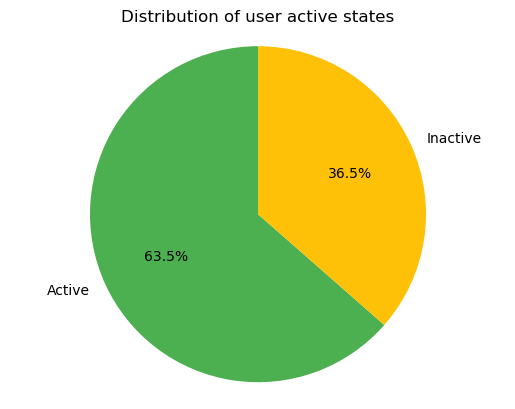

In [56]:
#Calculate ratio of active to all users
#Visualization
active_percentage = df['active'].mean() * 100

print(f"The percentage of active users is:{active_percentage:.2f}%")

fig, ax = plt.subplots()
ax.pie(df['active'].value_counts(), labels=['Active', 'Inactive'], autopct='%1.1f%%', startangle=90,
       colors=['#4CAF50', '#FFC107'])
ax.axis('equal')  
# Equal aspect ratio ensures that pie is drawn as a circle.

plt.title('Distribution of user active states')

plt.show()

Unsurprisingly the classes are imbalanced, but not tremendously. This should not present too much of a problem while modeling.

c. In the cell below, show a visualization that you used to select features for your model.

Include:

1. At least one plot showing something meaningful about the data that helped you during feature selection, model selection, or both.

2. Two or three sentences describing what you plotted and its implications with respect to your features.



/Users/mac/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


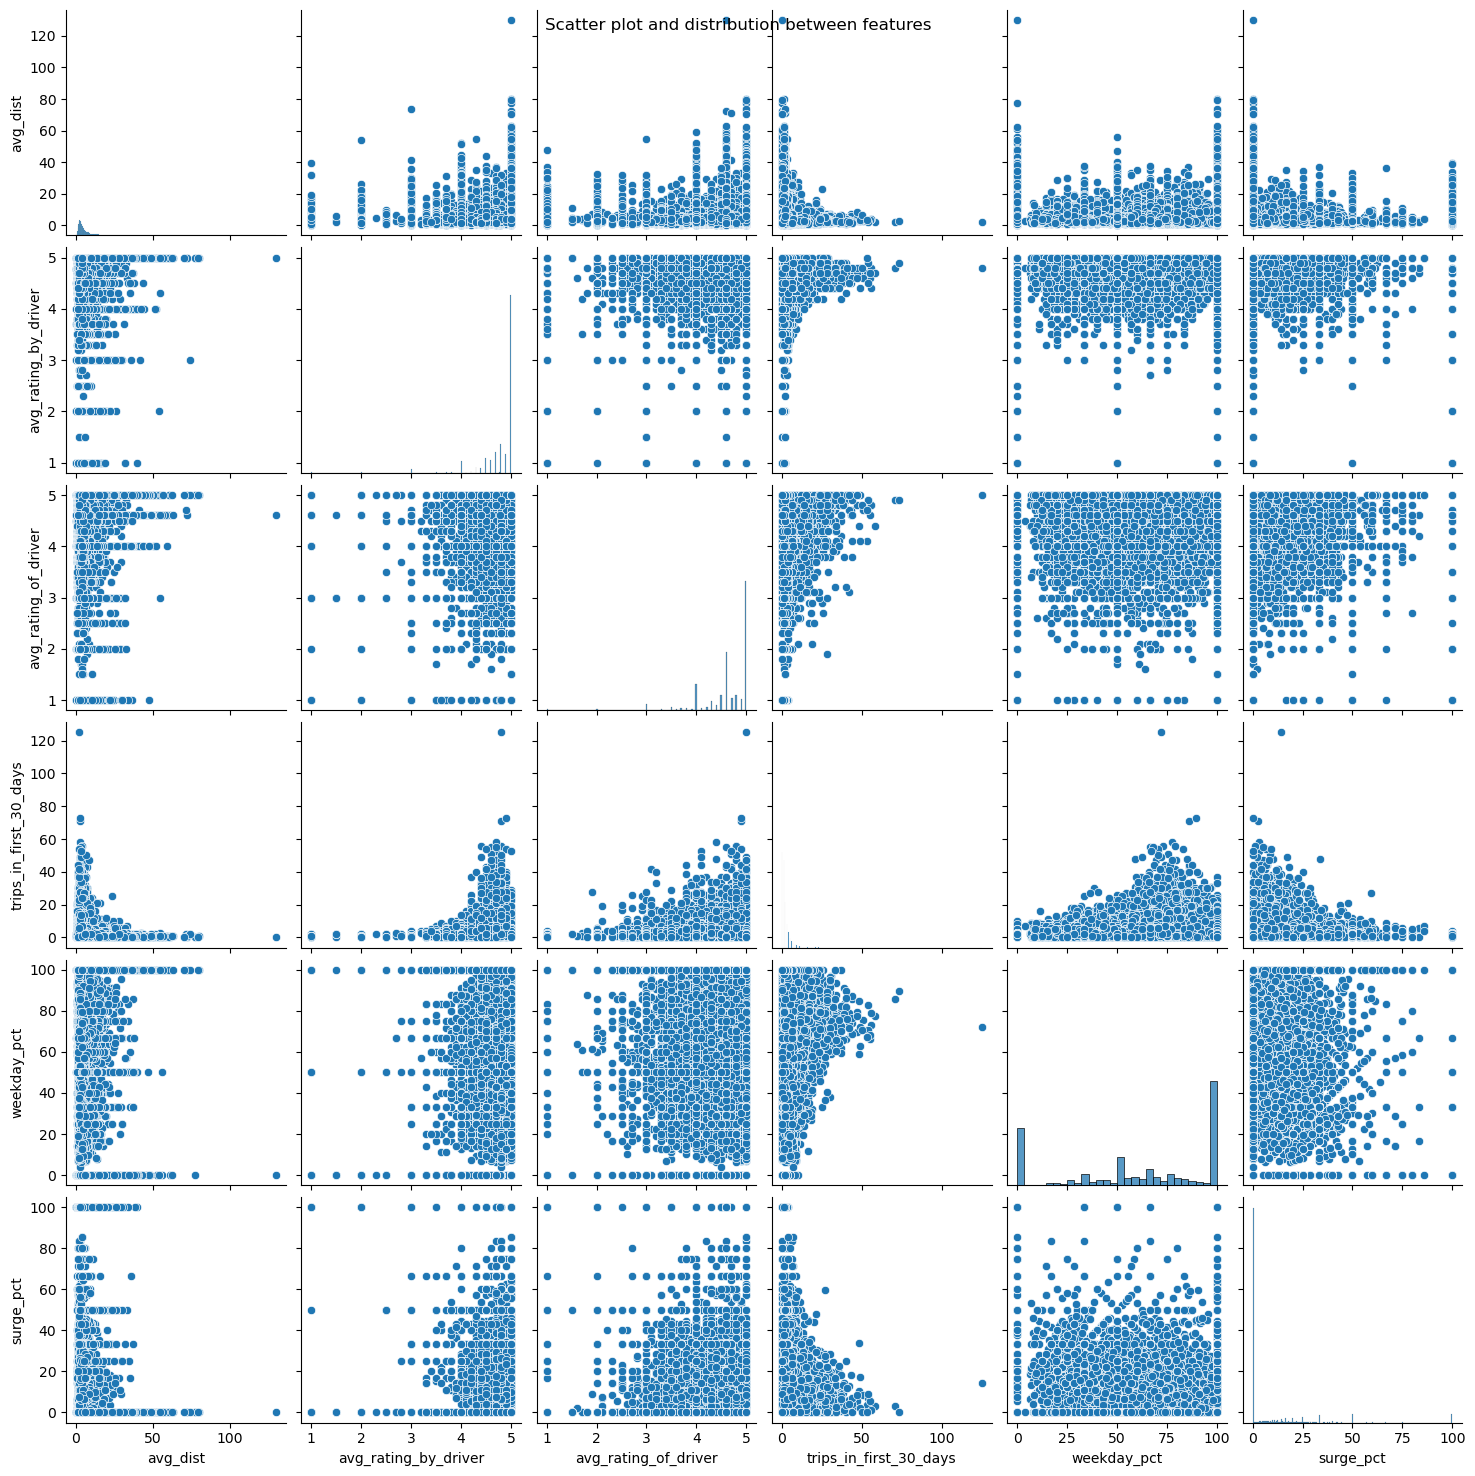

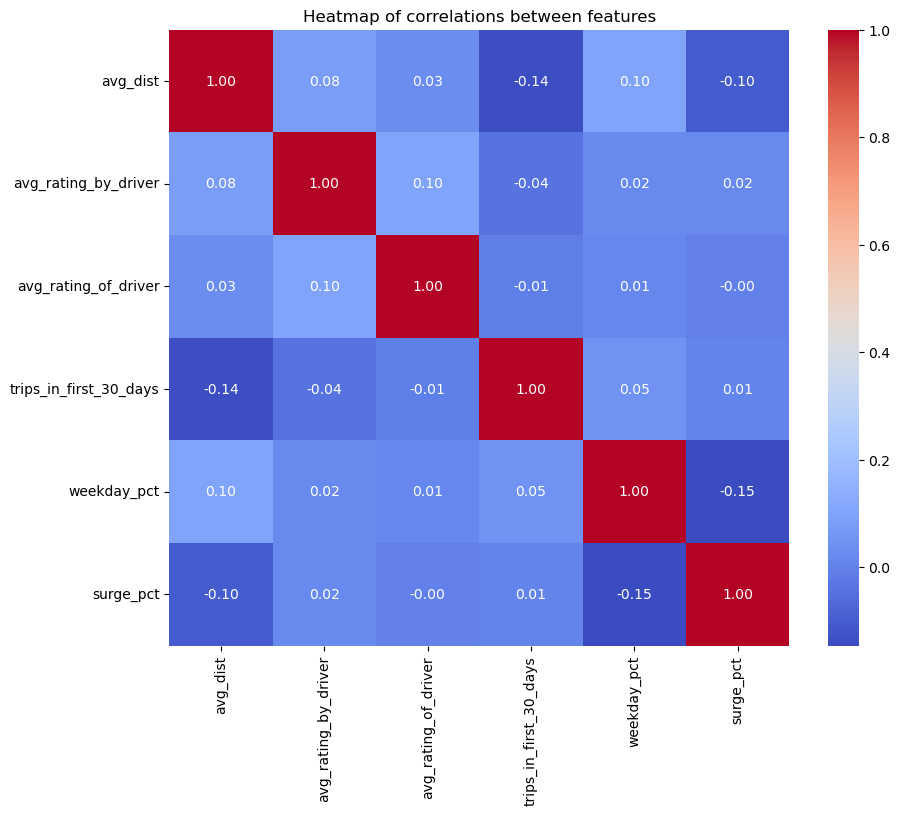

In [57]:
features = ['avg_dist', 'avg_rating_by_driver', 'avg_rating_of_driver', 'trips_in_first_30_days', 'weekday_pct',
            'surge_pct']

sns.pairplot(df[features])
plt.suptitle('Scatter plot and distribution between features')
plt.show()

correlation_matrix = df[features].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap of correlations between features')
plt.show()

## 2. Modeling

Now, please perform feature engineering to build a model that can predict whether the users are active. (To get full credit, you need to make some visualization and try out several different models using cross validation)

In [58]:
df['rating_difference'] = abs(df['avg_rating_by_driver'] - df['avg_rating_of_driver'])

In [59]:
df['rating_difference']

0        1.3
1        0.0
2        2.0
3        1.0
4        0.2
        ... 
47495    1.0
47496    0.0
47497    0.5
47498    0.0
47499    2.0
Name: rating_difference, Length: 47500, dtype: float64

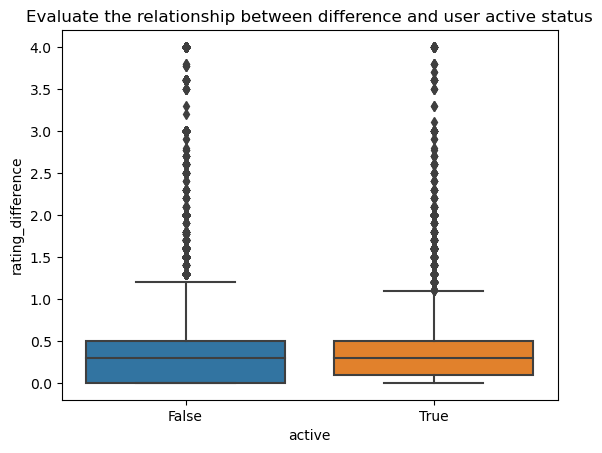

In [60]:
sns.boxplot(x='active', y='rating_difference', data=df)
plt.title('Evaluate the relationship between difference and user active status')
plt.show()

In [61]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

X = df[['avg_dist', 'trips_in_first_30_days', 'weekday_pct', 'rating_difference', 'surge_pct']]
y = df['active']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier()
}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=10)
    print(f"{name} Accuracy: {scores.mean():.2f} (+/- {scores.std() * 2:.2f})")


Logistic Regression Accuracy: 0.66 (+/- 0.01)
Random Forest Accuracy: 0.70 (+/- 0.01)



## 3. Model Evaluation

The bottom line here is: Was the model useful? You need to check both **numerical metrics and visual metrics**. **Please explain different performance metrics and your results.**

In [62]:
from sklearn.metrics import classification_report, confusion_matrix

model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]  

print(classification_report(y_test, y_pred))
confusion_matrix(y_test, y_pred)


              precision    recall  f1-score   support

       False       0.76      0.75      0.76      9073
        True       0.57      0.58      0.58      5177

    accuracy                           0.69     14250
   macro avg       0.67      0.67      0.67     14250
weighted avg       0.69      0.69      0.69     14250



array([[6829, 2244],
       [2171, 3006]])

## 4. Final Submission




The following code will write your predictions on the test dataset to a CSV file. **You will need to submit this file to get credit for this question.**

Save your predictions in a 1-dimensional array called `test_predictions` (contains 0 and 1s). 

Remember that if you've performed transformations or featurization on the training data, you must also perform the same transformations on the test data in order to make predictions. 



### Submission on Gitea

Please push all your work (ipynb, submission.csv) to the `-final` repo on Gitea. All your work should be on the master branch. 

### Submission on Canvas

Just in case you have issues with Git, submit the same items on Canvas.



In [65]:
test = pd.read_csv('test.csv')

test['avg_rating_by_driver'].fillna(df['avg_rating_by_driver'].mean(), inplace=True)
test['avg_rating_of_driver'].fillna(df['avg_rating_of_driver'].mean(), inplace=True)

test['rating_difference'] = abs(test['avg_rating_by_driver'] - test['avg_rating_of_driver'])

X_test = test[['avg_dist', 'trips_in_first_30_days', 'weekday_pct', 'rating_difference', 'surge_pct']]

test_predictions = model.predict(X_test).astype(int)

In [66]:
submission_df = pd.DataFrame({
    "active": test_predictions
}, columns=['active'])
submission_df.to_csv("submission.csv", index=False)

print('Created a CSV file: submission.csv')
print('You may now upload this CSV file to Canvas for grading.')

Created a CSV file: submission.csv
You may now upload this CSV file to Canvas for grading.
